<a href="https://colab.research.google.com/github/pepetonof/EvolutionaryNeuralArchitectureSearch-HUMai-AR2026/blob/main/DeepGA_Humai_share.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Código para el taller "Experiencias con Evolutionary Neural Architecture Search"**


Jesús Arnulfo Barradas Palmeros [[Google Scholar](https://scholar.google.com/citations?user=QlQPfXgAAAAJ&hl)][[ORCID](https://orcid.org/0009-0008-1187-4981)][[ResearhGate](https://www.researchgate.net/profile/Jesus-Arnulfo-Barradas-Palmeros)]

---

BreastMNIST de MedMNIST+ se propone como un dataset para experimentación rápida. DeepGA se usa como estrategia de búsqueda y se consideran el desempeño y la complejidad de la red como criterios de diseño.

**Trabajo más reciente:**
> Barradas-Palmeros, J.A., Quiroz-Castellanos, M., López-Herrera, C.A., Mezura-Montes, E., Acosta-Mesa, H.G., & Falcón-Cardona, J.G. (2026). *Reproduction Strategies in Evolutionary Neural Architecture Search: An Experimental Study with DeepGA*. In 2026 IEEE Congress on Evolutionary Computation (CEC). IEEE. (In press) [[GitHub](https://github.com/JABarradas/WCCI2026)]

El artículo fue aceptado y será presentado como parte del IEEE World Congress on Computational Intelligence ([WCCI](https://attend.ieee.org/wcci-2026/)) 2026.

**DeepGA fue propuesto en:**

> Vargas-Hákim, G. A., Mezura-Montes, E., & Acosta-Mesa, H. G. (2021). *Hybrid encodings for neuroevolution of convolutional neural networks: a case study*. In Proceedings of the Genetic and Evolutionary Computation Conference Companion (pp. 1762-1770). DOI: [10.1145/3449726.3463133](https://doi.org/10.1145/3449726.3463133) [[GitHub](https://github.com/GustavoVargasHakim/DeepGA)]




**Estudios sobre DeepGA:**

| *Conference/Journal*  | *Paper*   |
| ------------- |:-------------|
| CIAPP 2024 | [Efficient Neural Architecture Search: Computational Cost Reduction Mechanisms in DeepGA](https://doi.org/10.1007/978-3-031-83882-8_12)   |
| MCA (JCR) 2025 | [Testing Neural Architecture Search Efficient Evaluation Methods in DeepGA](https://doi.org/10.3390/mca30040074)   |
| LACCI 2025 | [Comparative Analysis of Parent Selection Strategies in DeepGA for Neural Architecture Search](https://doi.org/10.1109/LA-CCI66231.2025.11270439)   |
| ENC 2025 | [Assessing the Impact of Network Regularizers on the Performance of Convolutional Neural Network Architectures Evolved by DeepGA](https://doi.org/10.1109/ENC68268.2025.11311921)   |


**Trabajos donde se ha aplicado DeepGA:**
|*Year* | *Domain* | *Paper* |
| ------------- |:-------------|:-------------|
|2025    | Climate   | [Optimization of LSTM networks through neuroevolution for drought forecasting in Mexico](https://doi.org/10.1007/s00704-025-05818-z)    |
|2024    | Medical    | [Use and Comparison of Machine Learning Techniques to Discern the Protein Patterns of Autoantibodies Present in Women with and without Breast Pathology](https://pubs.acs.org/doi/10.1021/acs.jproteome.4c00759)    |
|2023    | Medical   | [Neuroevolution of Convolutional Neural Networks for Breast Cancer Diagnosis Using Western Blot Strips](https://doi.org/10.3390/mca28030072)   |
|2024    | Agriculture   | [Estimation of Anthocyanins in Heterogeneous and Homogeneous Bean Landraces Using Probabilistic Colorimetric Representation with a Neuroevolutionary Approach](https://doi.org/10.3390/mca29040068)    |
|2023    | Agriculture   | [Estimation of Anthocyanins in Homogeneous Bean Landraces Using Neuroevolution](https://doi.org/10.1007/978-3-031-51940-6_28)    |
|2023    | Automobile   | [Vehicle Make and Model Recognition as an Open-Set Recognition Problem and New Class Discovery](https://doi.org/10.3390/mca28040080)   |
|2024    | Automobile   | [Reducing Parameters by Neuroevolution in CNN for Steering Angle Estimation](https://doi.org/10.1007/978-3-031-62836-8_35)   |



# Installing MedMNIST

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.6 MB/s eta 0:00:00


#Encoding class

In [ ]:
import random

'''Hyperparameters configuration'''
#Convolutional layers
FSIZES = [3,5]
NFILTERS = [16,32,64,128]

#Pooling layers
PSIZES = [2,3]
PTYPE = ['max', 'avg']

#Fully connected layers
NEURONS = [16,32,64,128,256]

class Encoding:
  def __init__(self, minC, maxC, minF, maxF):
    self.n_conv = random.randint(minC, maxC)
    self.n_full = random.randint(minF, maxF)


    '''First level encoding'''
    self.first_level = []

    #Feature extraction part
    for i in range(self.n_conv):
      layer = {'type' : 'conv',
                'nfilters' : random.choice(NFILTERS),
                'fsize' : random.choice(FSIZES),
                'pool' : random.choice(['max', 'avg', 'off']),
                'psize' : random.choice(PSIZES)
              }
      self.first_level.append(layer)

    #Fully connected part
    for i in range(self.n_full):
      layer = {'type' : 'fc',
                'neurons' : random.choice(NEURONS)}

      self.first_level.append(layer)


    '''Second level encoding'''
    self.second_level = []
    prev = -1
    for i in range(self.n_conv):
      if prev < 1:
        prev += 1
      if prev >= 1:
        for _ in range(prev-1):
            self.second_level.append(random.choice([0,1]))
        prev += 1



In [ ]:
def print_encoding(enc):
    print("FIRST LEVEL")
    print("-" * 40)

    conv_count = 1
    fc_count = 1

    for layer in enc.first_level:

        if layer["type"] == "conv":

            print(
                f"[Conv {conv_count}] "
                f"Filters: {layer['nfilters']} | "
                f"Kernel: {layer['fsize']}"
            )

            if layer["pool"] == "off":
                print("         Pooling: off")

            else:
                print(
                    f"         Pooling: {layer['pool']} | "
                    f"Size: {layer['psize']}"
                )

            conv_count += 1

        elif layer["type"] == "fc":
            if fc_count == 1:
              print()

            print(
                f"[FC {fc_count}] "
                f"Neurons: {layer['neurons']}"
            )

            fc_count += 1

    print("-" * 40)
    print("SECOND LEVEL")

    #binary_string = "".join(map(str, enc.second_level))

    print(enc.second_level)

# Decoding

In [ ]:
from torch import nn
import math
import torch

# Using pad = 1
def conv_out_size(W, K):
  return W - K + 3
# Using pad = 'same'
#def conv_out_size(W, K):
#  return W

def pool_out_size(W, K):
  return math.floor((W - K)/2) + 1

def decoding(encoding, img_size=64, img_chann=1, no_classes=2):
  n_conv = encoding.n_conv
  n_full = encoding.n_full
  first_level = encoding.first_level
  second_level = encoding.second_level

  features = []
  classifier = []
  in_channels = img_chann
  out_size = img_size
  prev = -1
  pos = 0
  o_sizes = []
  for i in range(n_conv):
    layer = first_level[i]
    n_filters = layer['nfilters']
    f_size = layer['fsize']
    pad = 1
    poolingtype = layer['pool']
    if out_size < 2:
      poolingtype = 'off'
    if f_size > out_size:
        f_size = out_size - 1
        if f_size < 1:
          f_size = 1
    if i == 0 or i == 1:
      if poolingtype == 'off':
        operation = [nn.Conv2d(in_channels = in_channels, out_channels = n_filters, kernel_size = f_size, padding = pad),
                    nn.BatchNorm2d(n_filters),
                    nn.ReLU(inplace = True)]
        in_channels = n_filters
        out_size = conv_out_size(out_size, f_size)
        o_sizes.append([out_size, in_channels])

      if poolingtype == 'avg':
          p_size = layer['psize']
          if p_size > out_size:
              p_size = out_size - 1
              if p_size < 1:
                p_size = 1
          operation = [nn.Conv2d(in_channels = in_channels, out_channels = n_filters, kernel_size = f_size, padding = pad),
                      nn.BatchNorm2d(n_filters),
                      nn.ReLU(inplace = True),
                      nn.AvgPool2d(kernel_size = p_size, stride = 2)]
          in_channels = n_filters
          out_size = conv_out_size(out_size, f_size)
          out_size = pool_out_size(out_size, p_size)
          o_sizes.append([out_size, in_channels])

      if poolingtype == 'max':
          p_size = layer['psize']
          if p_size > out_size:
              p_size = out_size - 1
              if p_size < 1:
                p_size = 1
          operation = [nn.Conv2d(in_channels = in_channels, out_channels = n_filters, kernel_size = f_size, padding = pad),
                      nn.BatchNorm2d(n_filters),
                      nn.ReLU(inplace = True),
                      nn.MaxPool2d(kernel_size = p_size, stride = 2)]
          in_channels = n_filters
          out_size = conv_out_size(out_size, f_size)
          out_size = pool_out_size(out_size, p_size)
          o_sizes.append([out_size, in_channels])
    else:
      connections = second_level[pos:pos+prev]
      for c in range(len(connections)):
        if connections[c] == 1:
          in_channels += o_sizes[c][1]

      if poolingtype == 'off':
        operation = [nn.Conv2d(in_channels = in_channels, out_channels = n_filters, kernel_size = f_size, padding = pad),
                    nn.BatchNorm2d(n_filters),
                    nn.ReLU(inplace = True)]
        in_channels = n_filters
        out_size = conv_out_size(out_size, f_size)
        o_sizes.append([out_size, in_channels])

      if poolingtype == 'avg':
          p_size = layer['psize']
          if p_size > out_size:
              p_size = out_size - 1
              if p_size < 1:
                p_size = 1
          operation = [nn.Conv2d(in_channels = in_channels, out_channels = n_filters, kernel_size = f_size, padding = pad),
                      nn.BatchNorm2d(n_filters),
                      nn.ReLU(inplace = True),
                      nn.AvgPool2d(kernel_size = p_size, stride = 2)]
          in_channels = n_filters
          out_size = conv_out_size(out_size, f_size)
          out_size = pool_out_size(out_size, p_size)
          o_sizes.append([out_size, in_channels])

      if poolingtype == 'max':
          p_size = layer['psize']
          if p_size > out_size:
              p_size = out_size - 1
              if p_size < 1:
                p_size = 1
          operation = [nn.Conv2d(in_channels = in_channels, out_channels = n_filters, kernel_size = f_size, padding = pad),
                      nn.BatchNorm2d(n_filters),
                      nn.ReLU(inplace = True),
                      nn.MaxPool2d(kernel_size = p_size, stride = 2)]
          in_channels = n_filters
          out_size = conv_out_size(out_size, f_size)
          out_size = pool_out_size(out_size, p_size)
          o_sizes.append([out_size, in_channels])

      pos += prev
    prev += 1

    features.append(operation)
  in_size = out_size*out_size*in_channels
  for i in range(n_conv,(n_conv + n_full)):
    layer = first_level[i]
    n_neurons = layer['neurons']
    classifier += [nn.Linear(in_size, n_neurons)]
    classifier += [nn.ReLU(inplace = True)]
    in_size = n_neurons

  ##Last layer generates the last neurons for softmax (change this for binary classification)
  classifier += [nn.Linear(n_neurons, no_classes)]

  return features, classifier, o_sizes


'''Networks class'''
class CNN(nn.Module):
  def __init__(self, encoding, features, classifier, sizes, init_weights = False):
    super(CNN, self).__init__()
    extraction = []
    for layer in features:
      extraction += layer
    self.extraction = nn.Sequential(*extraction)
    self.classifier = nn.Sequential(*classifier)
    self.features = features
    self.second_level = encoding.second_level
    self.sizes = sizes

    # Apply He initialization
    if init_weights:
        self.initialize_weights()

  def initialize_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
          nn.init.zeros_(m.bias)
      elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
          nn.init.zeros_(m.bias)

  def forward(self, x):
    '''Feature extraction'''
    prev = -1
    pos = 0
    outputs = {}
    features = self.features
    #print(x.shape)
    for i in range(len(features)):
      #print('Layer: ', i)
      if i == 0 or i == 1:
        x = nn.Sequential(*features[i])(x)
        outputs[i] = x
        #print(x.shape)

      else:
        connections = self.second_level[pos:pos+prev]
        for c in range(len(connections)):
          if connections[c] == 1:
            skip_size = self.sizes[c][0] #Size comming from previous layer
            req_size = x.shape[2] #Current feature map size
            #print('X: ',x.shape)
            if skip_size > req_size:
              psize = skip_size - req_size + 1
              pool = nn.MaxPool2d(kernel_size = psize, stride = 1) #Applying pooling to adjust sizes
              x2 = pool(outputs[c])
            if skip_size == req_size:
              x2 = outputs[c]
            if skip_size < req_size:
              if (req_size - skip_size) % 2 == 0:
                pad = int((req_size - skip_size) / 2)
                padding = nn.ZeroPad2d(pad)
                x2 = padding(outputs[c])
              else:
                pool = nn.MaxPool2d(kernel_size = 2, stride = 1, padding = 1)
                x2 = pool(outputs[c]) #Sum 1 to outputs[c] size
                pad = int((req_size - skip_size - 1) / 2)
                if pad > 0:
                  padding = nn.ZeroPad2d(pad)
                  x2 = padding(x2)
            #print('X2: ',x2.shape)
            x = torch.cat((x, x2), axis = 1)

        x = nn.Sequential(*features[i])(x)
        #print('Out size: ', x.shape)
        outputs[i] = x
        pos += prev

      prev += 1

    #print('Classification size: ', x.shape)
    x = torch.flatten(x,1)
    '''Classification'''
    '''for l in self.classifier:
      x = l(x)'''
    x = self.classifier(x)
    #print(x.shape)
    return nn.functional.log_softmax(x, dim=1)

# Operators

In [ ]:
import random
import math
from copy import deepcopy

def crossover(x, y):
    x = deepcopy(x)
    y = deepcopy(y)

    '''First parent'''
    x_nconv = x.n_conv
    x_nfull = x.n_full
    xblocks = x.first_level
    xbinary = x.second_level

    '''Second parent'''
    y_nconv = y.n_conv
    y_nfull = y.n_full
    yblocks = y.first_level
    ybinary = y.second_level

    '''Convolutional part crossover'''
    if x_nconv > y_nconv:
        k = math.floor(y_nconv/2)
        index = list(range(x_nconv))

        '''Exchanging the last k blocks of the smaller parent'''
        for i in range(k, y_nconv):
            block = yblocks[i] #ith block
            ix = random.choice(index) #Selecting random index from larger parent
            index.remove(ix)

            #Exchange of blocks
            yblocks[i] = xblocks[ix]
            xblocks[ix] = block

    if y_nconv > x_nconv:
        k = math.floor(x_nconv/2)
        index = list(range(y_nconv))

        '''Exchanging the last k blocks of the smaller parent'''
        for i in range(k, x_nconv):
            block = xblocks[i] #ith block
            ix = random.choice(index) #Selecting random index from larger parent
            index.remove(ix)

            #Exchange of blocks
            xblocks[i] = yblocks[ix]
            yblocks[ix] = block

    if x_nconv == y_nconv:
        k = math.floor(x_nconv/2)
        index = list(range(x_nconv))

        x_part = xblocks[k:x_nconv]

        '''Exchaning last half of the blocks'''
        xblocks[k:x_nconv] = yblocks[k:y_nconv]
        yblocks[k:y_nconv] = x_part

    '''Fully-connected part'''
    if x_nfull > y_nfull:
        k = math.floor(y_nfull/2)
        index = list(range(x_nconv, x_nconv + x_nfull))

        '''Exchanging the last k blocks of the smaller parent'''
        for i in range(y_nconv + k, y_nconv + y_nfull):
            block = yblocks[i] #ith block
            ix = random.choice(index) #Selecting random index from larger parent
            index.remove(ix)

            #Exchange of blocks
            yblocks[i] = xblocks[ix]
            xblocks[ix] = block

    if y_nfull > x_nfull:
        k = math.floor(x_nfull/2)
        index = list(range(y_nconv, y_nconv + y_nfull))

        '''Exchanging the last k blocks of the smaller parent'''
        for i in range(x_nconv + k, x_nconv + x_nfull):
            block = xblocks[i] #ith block
            ix = random.choice(index) #Selecting random index from larger parent
            index.remove(ix)

            #Exchange of blocks
            xblocks[i] = yblocks[ix]
            yblocks[ix] = block

    if x_nfull == y_nfull:
        k = math.floor(x_nfull/2)

        x_part = xblocks[x_nconv + k:x_nconv + x_nfull]
        '''Exchaning last half of the blocks'''
        xblocks[x_nconv + k:x_nconv + x_nfull] = yblocks[y_nconv + k:y_nconv + y_nfull]
        yblocks[y_nconv + k:y_nconv + y_nfull] = x_part

    '''Second level'''
    if len(xbinary) > len(ybinary):
        if len(ybinary) > 1 :
            k = random.choice(list(range(1, len(ybinary))))
            partition = ybinary[k:]
            nbits = len(partition)

            if random.uniform(0,1) >= 0.5:
                ybinary[k:] = xbinary[len(xbinary) - nbits:len(xbinary)]
                xbinary[len(xbinary) - nbits:len(xbinary)] = partition
            else:
                ybinary[k:] = xbinary[:nbits]
                xbinary[:nbits] = partition

    if len(ybinary) > len(xbinary):
        if len(xbinary) > 1 :
            k = random.choice(list(range(len(xbinary))))
            partition = xbinary[k:]
            nbits = len(partition)

            if random.uniform(0,1) >= 0.5:
                xbinary[k:] = ybinary[len(ybinary) - nbits:len(ybinary)]
                ybinary[len(ybinary) - nbits:len(ybinary)] = partition
            else:
                xbinary[k:] = ybinary[:nbits]
                ybinary[:nbits] = partition

    if len(xbinary) == len(ybinary):
        if len(xbinary) > 1 :
            k = random.choice(list(range(len(xbinary))))
            partition = xbinary[k:]

            xbinary[k:] = ybinary[k:]
            ybinary[k:] = partition

    return x, y

def mutation(x):
    if random.uniform(0,1) < 0.5:
        '''Adding a new block'''
        if random.uniform(0,1) > 0.5:
            #Adding a fully-connected block
            layer = {'type' : 'fc',
                     'neurons' : random.choice(NEURONS)}

            #Choosing a random index to insert the new block
            index = list(range(x.n_conv, x.n_conv + x.n_full))
            ix = random.choice(index)

            x.first_level.insert(ix, layer)
            x.n_full += 1

        else:
            #Adding a convolutional block
            layer = {'type' : 'conv',
                     'nfilters' : random.choice(NFILTERS),
                     'fsize' : random.choice(FSIZES),
                     'pool' : random.choice(['max', 'avg', 'off']),
                     'psize' : random.choice(PSIZES)
                    }
            #Choosing a random index to insert the new block
            index = list(range(x.n_conv))
            ix = random.choice(index)

            x.first_level.insert(ix, layer)
            x.n_conv += 1

            if ix > 1:
                new_bits = []
                for i in range(ix - 1):
                    new_bits.append(random.choice([0,1]))
                pos = int(0.5*(ix**2) - 1.5*(ix) + 1)
                start = pos + len(new_bits)
                for bit in new_bits:
                    x.second_level.insert(pos, bit)
                    pos += 1

                rest = x.n_conv - ix - 1
                add = ix
                for j in range(rest):
                    x.second_level.insert(start+add-1, random.choice([0,1]))
                    start += add
                    ix += 1

            if ix == 0 or ix == 1:
                if x.n_conv - 1 == 2:
                    x.second_level.append(random.choice([0,1]))
                else:
                    add = 0
                    for i in range(2, x.n_conv):
                        pos = int(0.5*(ix**2) - 1.5*(ix) + 1) + add
                        x.second_level.insert(pos, random.choice([0,1]))
                        add += 1

    else:
        '''Changing hyperparameters in one block'''
        if random.uniform(0,1) > 0.5:
            '''Re-starting a fully-connected block'''
            index = list(range(x.n_conv, x.n_conv + x.n_full))
            ix = random.choice(index)
            new_layer = {'type' : 'fc',
                         'neurons' : random.choice(NEURONS)}
            #Switching fully-connected block
            x.first_level[ix] = new_layer

        else:
            '''Re-starting a convolutional block'''
            index = list(range(x.n_conv))
            ix = random.choice(index)
            new_layer = {'type' : 'conv',
                     'nfilters' : random.choice(NFILTERS),
                     'fsize' : random.choice(FSIZES),
                     'pool' : random.choice(['max', 'avg', 'off']),
                     'psize' : random.choice(PSIZES)
                    }

            #Switching convolutional block
            x.first_level[ix] = new_layer

        '''Modifying connections in second level'''
        if len(x.second_level) > 0:
            k = random.choice(list(range(len(x.second_level))))
            #Flipping one bit in the second level
            if x.second_level[k] == 1:
                x.second_level[k] = 0
            else:
                x.second_level[k] = 1


def selection(tournament, style):
    '''Stochastic tournament selection'''
    if style == 'max':
        if random.uniform(0,1) <= 0.8:
            p = max(tournament, key = lambda x: x[1])
        else:
            p = random.choice(tournament)
    else:
        if random.uniform(0,1) <= 0.8:
            p = min(tournament, key = lambda x: x[1])
        else:
            p = random.choice(tournament)

    return p


#random.seed(0)
#e1 = Encoding(2,8,1,4)
#e2 = Encoding(2,8,1,4)
#e2 = Encoding(8,8,4,4)

#c1, c2 = crossover(e1,e2)

# Distribuited training

In [ ]:
import torch
from torch import nn
from torch import optim
import gc

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

#Helper function to compute de loss on a batch
def loss_batch(loss_func, xb, yb, yb_h, opt = None):
  #Obtain the loss
  loss = loss_func(yb_h, yb)
  #Obtain peformance metric
  metric_b = metrics_batch(yb, yb_h)
  if opt is not None:
    loss.backward()
    opt.step()
    opt.zero_grad()

  return loss.item(), metric_b
  #return metric_b

#Helper function to compute the accuracy per mini_batch
def metrics_batch(target, output):
  #Obtain output class
  pred = output.argmax(dim=1, keepdim = True)
  #Compare output class with target class
  corrects = pred.eq(target.view_as(pred)).sum().item()

  return corrects

#Helper function to compute the loss and metric values for a dataset
def loss_epoch(device, model, loss_func, dataset_dl, opt = None):
  loss = 0.0
  metric = 0.0
  len_data = len(dataset_dl.dataset)
  for i, data in enumerate(dataset_dl, 0):
    #print('batch: ', i)
    #xb, yb = data['image'], data['label']
    xb, yb = data
    xb = xb.type(torch.double).to(device, dtype = torch.float32)
    yb = yb.to(device, dtype = torch.long)

    #Obtain model output
    yb_h = model(xb)

    loss_b, metric_b = loss_batch(loss_func, xb, yb, yb_h, opt)
    #metric_b = loss_batch(loss_func, xb, yb, yb_h, opt)
    loss += loss_b
    if metric_b is not None:
      metric += metric_b

  loss /= len_data
  metric /= len_data

  return loss, metric
  #return metric

#Define the training function
def train_val(device, epochs, model, opt, loss_func, train_dl, test_dl):

  for epoch in range(epochs):
    #print(epoch)
    model.train()
    train_loss, train_metric = loss_epoch(device, model, loss_func, train_dl, opt)
    #train_metric = loss_epoch(model, loss_func, train_dl, opt)
    model.eval()
    with torch.no_grad():
      val_loss, val_metric = loss_epoch(device, model, loss_func, test_dl)
      #val_metric = loss_epoch(model, loss_func, test_dl)
    accuracy = val_metric

    #print("Epoch: %d, train loss: %.6f, val loss: %.6f, test accuracy: %.2f" %(epoch, train_loss, val_loss, accuracy))

  return accuracy, model


def training(num, device, model, n_epochs, loss_func, train_dl, test_dl, lr, w, max_params):
    #Number of parameters
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    model.to(device)

    #Optimizer
    opt = optim.Adam(model.parameters(), lr = lr)

    #Obtaining training accuracy
    accuracy, _ = train_val(device, n_epochs, model, opt, loss_func, train_dl, test_dl)

    #Fitness function based on accuracy and No. of parameters
    f = (1 - w)*accuracy + w*((max_params - params)/max_params)

    del opt
    clear_memory()

    return f, accuracy, params


# Data reader

BreastMNIST

## Search process

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.v2 as v2
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np
import medmnist
from medmnist import INFO

def loading_data0(data_flag='breastmnist', image_size=28, batch=24):
    '''
    Important:
    This implementation of loading_data is intended for single-label
    classification datasets like breastmnist or bloodmnist
    '''
    info = INFO[data_flag]
    DataClass = getattr(medmnist, info['python_class'])

    # Target transform: ensures labels have shape (,) and dtype long
    target_transform = lambda y: torch.tensor(y).long().squeeze()

    # Training transforms
    transform_train = transforms.ToTensor()
    transform_test = transforms.ToTensor()

    # Load BreastMNIST
    trainset = DataClass(split='train',
                         transform=transform_train,
                         target_transform=target_transform,
                         download=True,
                         size=image_size)

    testset = DataClass(split='test',
                        transform=transform_test,
                        target_transform=target_transform,
                        download=True,
                        size=image_size)

    # DataLoaders
    train_dl = DataLoader(trainset, batch_size=batch, shuffle=True)
    test_dl  = DataLoader(testset,  batch_size=batch, shuffle=False)

    return train_dl, test_dl


In [ ]:
train_dlt, test_dlt = loading_data0()
variab, etiqueta = next(iter(train_dlt))
variab.shape

100%|██████████| 560k/560k [00:01<00:00, 473kB/s]


torch.Size([24, 1, 28, 28])

In [ ]:
len(train_dlt)

23

# DeepGA

In [ ]:
import numpy as np
from torch import optim
import pandas as pd
import timeit
import torch
from torch import nn
import pickle
from pathlib import Path
import copy
from copy import deepcopy
import random

def deepGA(train_epochs: int, img_size=28):
  '''
  ====================================================================
  Loading the dataset and initial configuration
  '''
  #Loading data
  image_size = img_size
  channels = 1
  no_classes = 2
  train_dl, test_dl = loading_data0(data_flag='breastmnist', image_size=image_size, batch=24)

  '''Defining CNN hyperparameters'''
  #Defining loss function
  loss_func = nn.CrossEntropyLoss()

  #Defining learning rate
  lr = 1e-4

  #Maximun and minimum numbers of layers to initialize networks
  min_conv = 2
  max_conv = 5
  min_full = 1
  max_full = 4

  '''Genetic Algorithm Parameters'''
  cr = 0.7 #Crossover rate
  mr = 0.5 #Mutation rate
  N = 20 #Population size
  T = 30 #Number of generations
  t_size = 3 #tournament size
  w = 0.1 #penalization weight
  max_params = 4e6
  num_epochs = train_epochs

  #Reading GPU
  device1 = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')

  '''
  ====================================================================
  Initialization of the population
  '''

  print('Initialize population')
  start = timeit.default_timer()
  pop = []
  bestAcc = []
  bestF = []
  bestParams = []
  t = 0  # Generaciones
  evals = 0 # Evaluaciones
  cacheM = {}
  meanfitpop = []
  meanAccpop = []
  meanParpop = []

  while len(pop) < N:
    #Creating genomes (genetic encoding)
    e1 = Encoding(min_conv,max_conv,min_full,max_full)

    strIDe1 = str([e1.n_conv, e1.n_full, e1.first_level, e1.second_level])
    if strIDe1 in cacheM:
      fit1 = cacheM[strIDe1][0]
      acc1 = cacheM[strIDe1][1]
      pars1 = cacheM[strIDe1][2]
    else:
      #Decoding the networks
      network1 = decoding(e1, img_size=image_size, img_chann=channels, no_classes=no_classes)
      #Creating the CNNs
      cnn1 = CNN(e1, network1[0], network1[1], network1[2])
      #Evaluate individuals
      fit1, acc1, pars1 = training('1', device1, cnn1, num_epochs, loss_func, train_dl, test_dl, lr, w, max_params)
      #Store fitness in memory
      cacheM[strIDe1] = [fit1, acc1, pars1]
      evals += 1

    print(fit1, acc1, pars1)
    pop.append([e1, fit1, acc1, pars1])
    del cnn1
    clear_memory()

  '''
  ====================================================================
  Genetic Algorithm: Evolutionary Process
  '''
  print('--------------------------------------------')
  while t < T:
    print('Generation: ', t)

    ''' Parent selection '''
    #Parents Selection
    parents = []
    while len(parents) < int(N/2):
      #Tournament Selection
      tournament = random.sample(pop, t_size)
      p1 = selection(tournament, 'max')
      tournament = random.sample(pop, t_size)
      p2 = selection(tournament, 'max')
      while p1 == p2:
        tournament = random.sample(pop, t_size)
        p2 = selection(tournament, 'max')

      parents.append(p1)
      parents.append(p2)

    '''Offspring creation with crossover and mutation '''
    #Reproduction
    offspring = []
    iter_parents = 0
    while len(offspring) < int(N/2):
      #Crossover + Mutation
      p1 = parents[iter_parents][0]
      p2 = parents[iter_parents + 1][0]
      if cr >= random.uniform(0,1): #Crossover
        c1, c2 = crossover(p1, p2)
      else:
        c1 = deepcopy(p1)
        c2 = deepcopy(p2)

      #Mutation
      if mr >= random.uniform(0,1):
        mutation(c1)

      if mr >= random.uniform(0,1):
        mutation(c2)

      #Evaluate offspring
      strIDc1 = str([c1.n_conv, c1.n_full, c1.first_level, c1.second_level])
      strIDc2 = str([c2.n_conv, c2.n_full, c2.first_level, c2.second_level])

      if strIDc1 in cacheM:
        fit1 = cacheM[strIDc1][0]
        acc1 = cacheM[strIDc1][1]
        pars1 = cacheM[strIDc1][2]
        print(fit1, acc1, pars1)
      else:
        network1 = decoding(c1, img_size=image_size, img_chann=channels, no_classes=no_classes)
        #Creating the CNN
        cnn1 = CNN(c1, network1[0], network1[1], network1[2])
        #Evaluate individuals
        fit1, acc1, pars1 = training('1', device1, cnn1, num_epochs, loss_func, train_dl, test_dl, lr, w, max_params)
        #Store fitness in memory
        cacheM[strIDc1] = [fit1, acc1, pars1]
        print(fit1, acc1, pars1)
        evals += 1

        del cnn1
        clear_memory()

      if strIDc2 in cacheM:
        fit2 = cacheM[strIDc2][0]
        acc2 = cacheM[strIDc2][1]
        pars2 = cacheM[strIDc2][2]
        print(fit2, acc2, pars2)
      else:
        #Decoding the network
        network2 = decoding(c2, img_size=image_size, img_chann=channels, no_classes=no_classes)
        #Creating the CNN
        cnn2 = CNN(c2, network2[0], network2[1], network2[2])
        #Evaluate individuals
        fit2, acc2, pars2 = training('1', device1, cnn2, num_epochs, loss_func, train_dl, test_dl, lr, w, max_params)
        #Store fitness in memory
        cacheM[strIDc2] = [fit2, acc2, pars2]
        print(fit2, acc2, pars2)
        evals += 1

        del cnn2
        clear_memory()

      offspring.append([c1, fit1, acc1, pars1])
      offspring.append([c2, fit2, acc2, pars2])

      iter_parents += 2

    ''' Replacement mechanism '''
    #Replacement with elitism
    pop = pop + offspring
    pop.sort(reverse = True, key = lambda x: x[1])
    pop = pop[:N]

    leader = max(pop, key = lambda x: x[1])
    bestAcc.append(leader[2])
    bestF.append(leader[1])
    bestParams.append(leader[3])
    meanfitpop.append(sum([q[1] for q in pop])/N)
    meanAccpop.append(sum([q[2] for q in pop])/N)
    meanParpop.append(sum([q[3] for q in pop])/N)

    t += 1

    print('Best fitness: ', leader[1])
    print('Best accuracy: ', leader[2])
    print('Best No. of Params: ', leader[3])
    print('No. of Conv. Layers: ', leader[0].n_conv)
    print('No. of FC Layers: ', leader[0].n_full)
    print('--------------------------------------------')

  leader = max(pop, key = lambda x: x[1])
  bestind = copy.deepcopy(leader)
  results = pd.DataFrame(list(zip(bestAcc, bestF, bestParams, meanfitpop,  meanAccpop, meanParpop)),
                         columns = ['Accuracy', 'Fitness', 'No. Params', 'MeanFit', 'MeanAcc', 'MeanPar'])
  print(results)

  print('\n====================================================================')
  print_encoding(bestind[0])
  print('====================================================================\n')


  stop = timeit.default_timer()
  execution_timeS = (stop-start)
  execution_timeH = execution_timeS/3600
  print("Execution time: ", execution_timeS, " seconds")
  print("Execution time: ", execution_timeH, " hours")
  print("Number of evaluations: ", evals)
  print("Accuracy Best individual: ", bestind[2])

  resultsfin = pd.DataFrame([[bestind[2], bestind[1], bestind[3], evals, execution_timeS]],
                            columns = ['Accuracy1', 'Fitness1', 'No. Params1', 'Evals', 'TimeS'])

  return results, resultsfin

In [ ]:
res, resf = deepGA(train_epochs=5, img_size=28)
resf

Initialize population
0.8470295807692307 0.8397435897435898 349586
0.8268834576923078 0.8141025641025641 232354
0.8375651807692308 0.8397435897435898 728162
0.8693017038461539 0.8653846153846154 381778
0.83923435 0.8333333333333334 430626
0.7239914576923077 0.7307692307692307 1348034
0.8045421346153847 0.7884615384615384 202930
0.8309839807692307 0.8397435897435898 991410
0.7663359192307693 0.7435897435897436 115794
0.8089549961538463 0.8012820512820513 487954
0.7547906576923077 0.7307692307692307 116066
0.8207830884615385 0.8205128205128205 707138
0.84356475 0.8333333333333334 257410
0.7958772730769231 0.7756410256410257 87986
0.7884448730769231 0.7756410256410257 385282
0.8074281346153847 0.7884615384615384 87490
0.8543685346153846 0.8717948717948718 1209874
0.7556670576923077 0.7307692307692307 81010
0.8350986884615386 0.8205128205128205 134514
0.83375195 0.8333333333333334 649922
--------------------------------------------
Generation:  0
0.8693017038461539 0.8653846153846154 38177

,Accuracy1,Fitness1,No. Params1,Evals,TimeS
0,0.884615,0.885345,432338,189,331.756028


In [ ]:
res, resf = deepGA(train_epochs=5, img_size=28)
resf

# Comparison with the state of the art:

Results from *Medmnist v2-a large-scale lightweight benchmark for 2d and 3d biomedical image classification. Scientific data* [1].

Table from
https://medmnist.com/



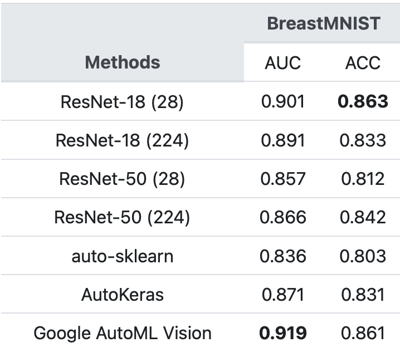

In [ ]:
from PIL import Image
img = Image.open('/content/MedMNIST.png')
img.thumbnail((400, 400))
img


Results from *Rethinking model prototyping through the MedMNIST+ dataset collection. Scientific reports* [2]

Tables from the paper and
https://github.com/sdoerrich97/rethinking-model-prototyping-MedMNISTPlus

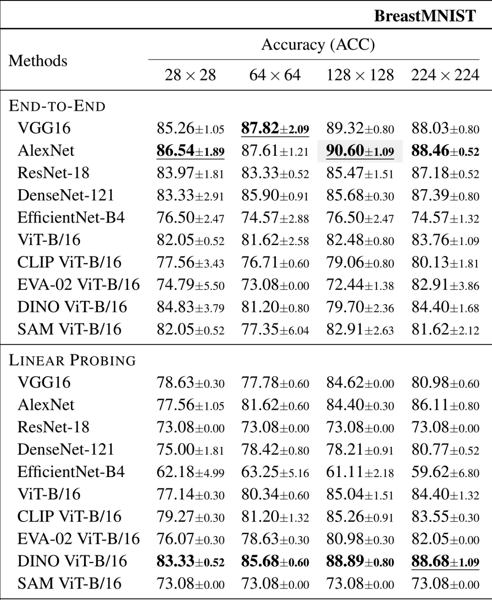

In [ ]:
img = Image.open('/content/MedMNIST2.png')
img.thumbnail((600, 600))
img

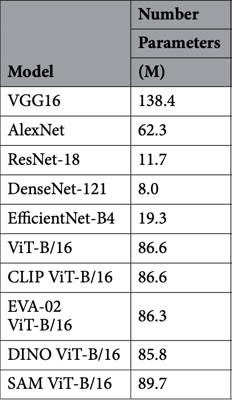

In [ ]:
img = Image.open('/content/MedMNIST3.png')
img.thumbnail((400, 400))
img

Rerefences:

[1] Yang, J., Shi, R., Wei, D., Liu, Z., Zhao, L., Ke, B., ... & Ni, B. (2023). Medmnist v2-a large-scale lightweight benchmark for 2d and 3d biomedical image classification. Scientific data, 10(1), 41.

[2] Doerrich, S., Di Salvo, F., Brockmann, J., & Ledig, C. (2025). Rethinking model prototyping through the MedMNIST+ dataset collection. Scientific reports, 15(1), 7669.